## Inteligență Artificială  Tema 1 - 2025: Sokoban

Responsabili:
- Andrei Olaru
- Cătălin Chiru
- Andrei Dugăeșescu
- Mihai Nan
- Vlad Matei Drăghici
- Alexandru Baciu
- Bogdan-Andrei Sprîncenatu

# Imports and Setup

In [ ]:
from sokoban import Map, save_images, create_gif
import time
from search_methods.lrta_star import LRTAStar
from search_methods.simmulated_annealing import SimulatedAnnealing
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd


# Test Map

In [ ]:
test_maps = [
    'tests/easy_map1.yaml',
    'tests/easy_map2.yaml',
    'tests/medium_map1.yaml',
    'tests/medium_map2.yaml',
    'tests/hard_map1.yaml',
    'tests/hard_map2.yaml',
    'tests/large_map1.yaml',
    'tests/large_map2.yaml',
    'tests/super_hard_map1.yaml'
]


=== Testing LRTA* Algorithm ===

Testing easy_map1.yaml...
Solution found with 165 moves
States explored: 3863
Pull moves used: 45
Time taken: 0.37 seconds
Initial state visualization saved easy_map1 


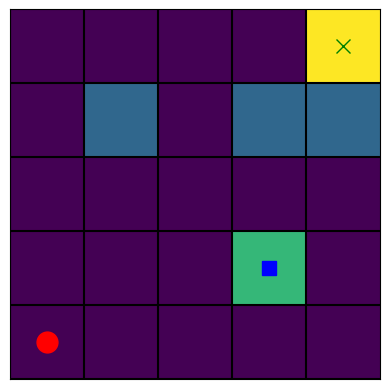

Final state visualization saved easy_map1 


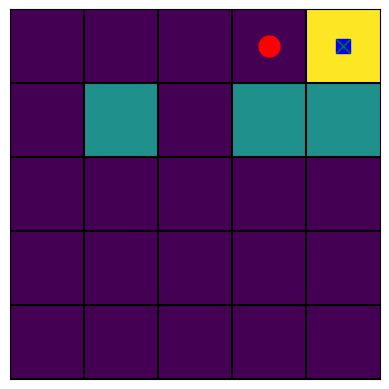


Solution visualization saved in tests/solutions/lrta*/easy_map1

Testing easy_map2.yaml...
Solution found with 15 moves
States explored: 15
Pull moves used: 4
Time taken: 0.01 seconds
Initial state visualization saved easy_map2 


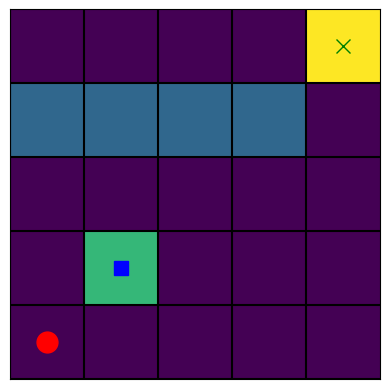

Final state visualization saved easy_map2 


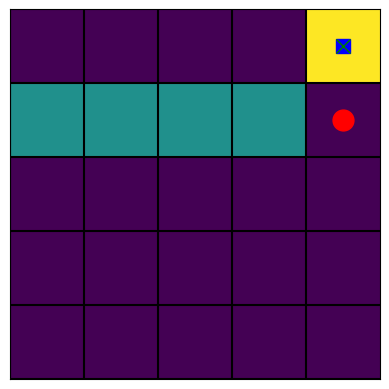


Solution visualization saved in tests/solutions/lrta*/easy_map2

Testing medium_map1.yaml...
Solution found with 29 moves
States explored: 29
Pull moves used: 11
Time taken: 0.01 seconds
Initial state visualization saved medium_map1 


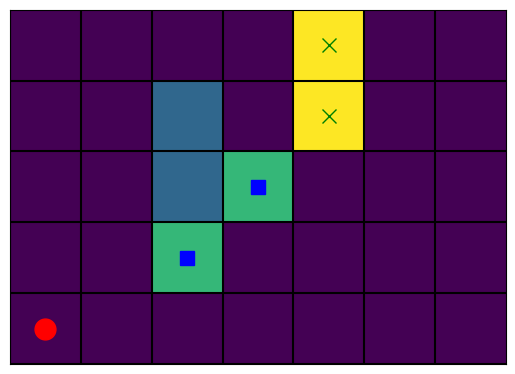

Final state visualization saved medium_map1 


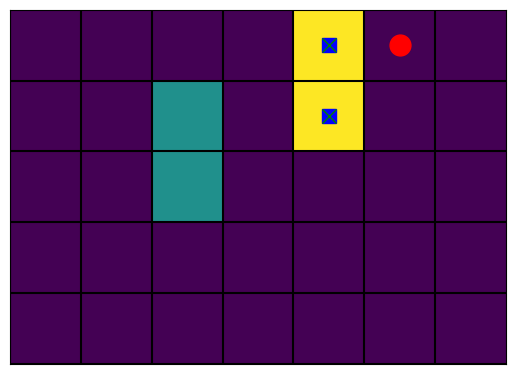


Solution visualization saved in tests/solutions/lrta*/medium_map1

Testing medium_map2.yaml...
Solution found with 1870 moves
States explored: 5545
Pull moves used: 525
Time taken: 1.55 seconds
Initial state visualization saved medium_map2 


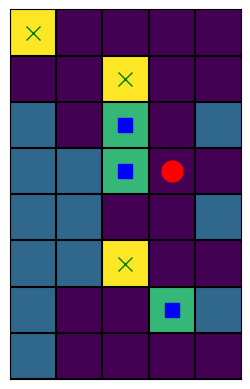

Final state visualization saved medium_map2 


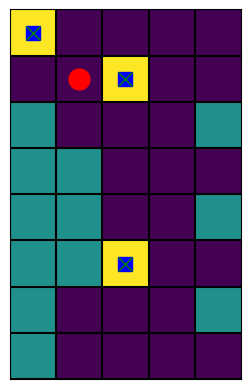


Solution visualization saved in tests/solutions/lrta*/medium_map2

Testing hard_map1.yaml...
Solution found with 1888 moves
States explored: 4938
Pull moves used: 673
Time taken: 2.79 seconds
Initial state visualization saved hard_map1 


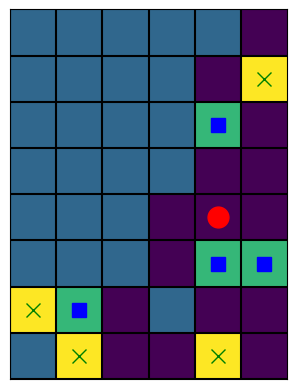

Final state visualization saved hard_map1 


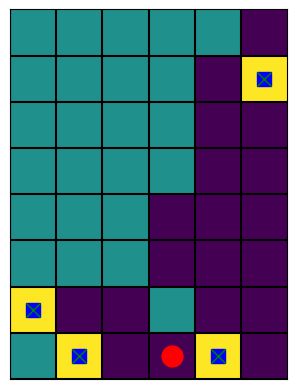


Solution visualization saved in tests/solutions/lrta*/hard_map1

Testing hard_map2.yaml...
Solution found with 1540 moves
States explored: 4803
Pull moves used: 422
Time taken: 1.23 seconds
Initial state visualization saved hard_map2 


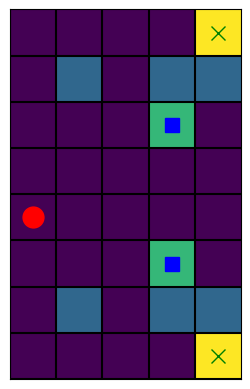

Final state visualization saved hard_map2 


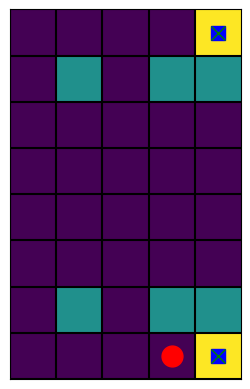


Solution visualization saved in tests/solutions/lrta*/hard_map2

Testing large_map1.yaml...
Solution found with 309 moves
States explored: 531
Pull moves used: 87
Time taken: 0.23 seconds
Initial state visualization saved large_map1 


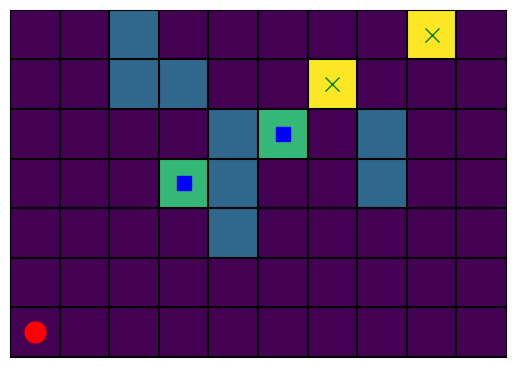

Final state visualization saved large_map1 


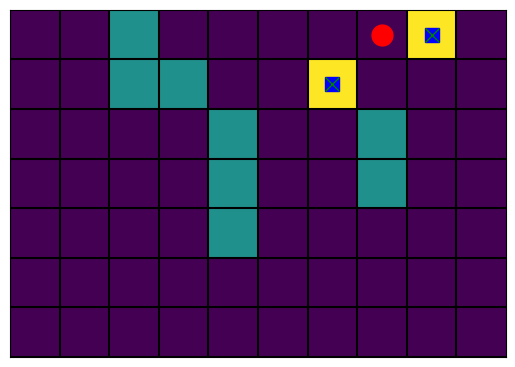


Solution visualization saved in tests/solutions/lrta*/large_map1

Testing large_map2.yaml...
Solution found with 894 moves
States explored: 2263
Pull moves used: 227
Time taken: 0.96 seconds
Initial state visualization saved large_map2 


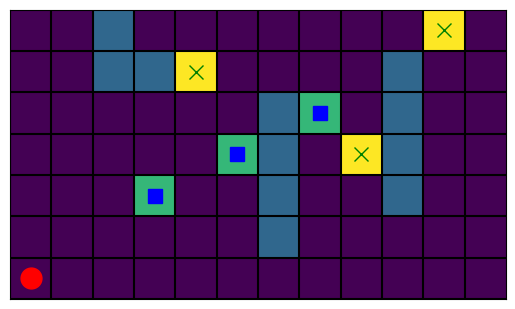

Final state visualization saved large_map2 


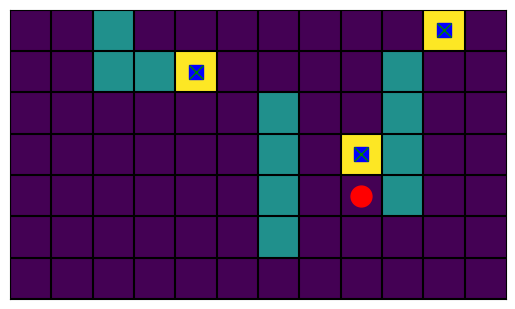


Solution visualization saved in tests/solutions/lrta*/large_map2

Testing super_hard_map1.yaml...
Solution found with 130 moves
States explored: 149
Pull moves used: 43
Time taken: 0.20 seconds
Initial state visualization saved super_hard_map1 


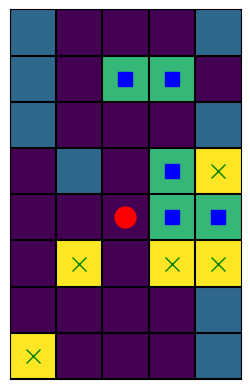

Final state visualization saved super_hard_map1 


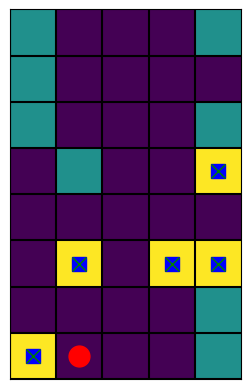


Solution visualization saved in tests/solutions/lrta*/super_hard_map1

=== Testing Simulated Annealing Algorithm ===

Testing easy_map1.yaml...
Solution found with 449 moves
States explored: 0
Pull moves used: 126
Time taken: 0.09 seconds
Initial state visualization saved easy_map1 


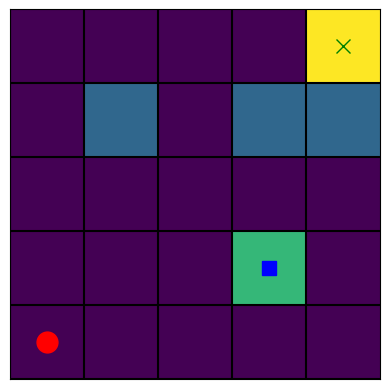

Final state visualization saved easy_map1 


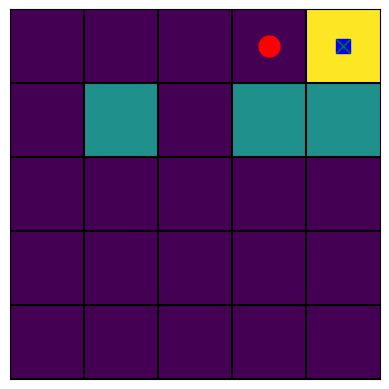


Solution visualization saved in tests/solutions/simulated_annealing/easy_map1

Testing easy_map2.yaml...
Solution found with 259 moves
States explored: 0
Pull moves used: 77
Time taken: 0.06 seconds
Initial state visualization saved easy_map2 


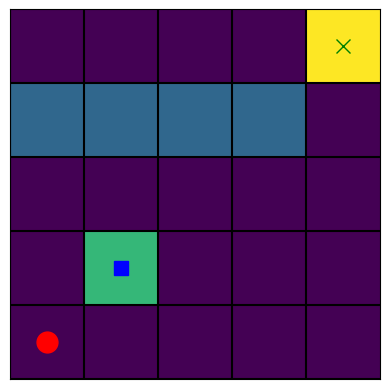

Final state visualization saved easy_map2 


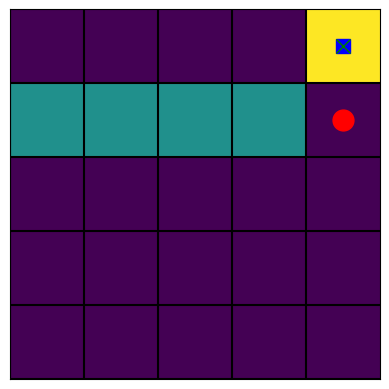


Solution visualization saved in tests/solutions/simulated_annealing/easy_map2

Testing medium_map1.yaml...
Solution found with 326 moves
States explored: 0
Pull moves used: 108
Time taken: 0.47 seconds
Initial state visualization saved medium_map1 


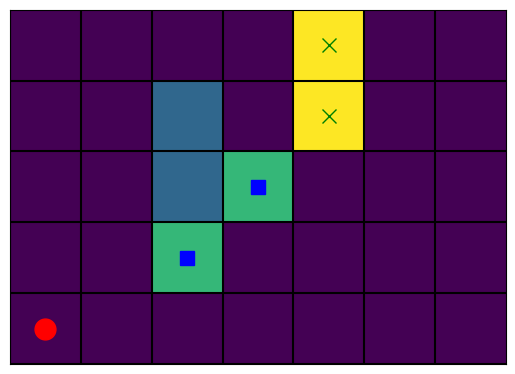

Final state visualization saved medium_map1 


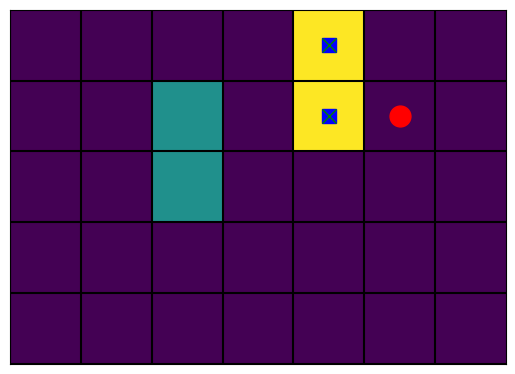


Solution visualization saved in tests/solutions/simulated_annealing/medium_map1

Testing medium_map2.yaml...
Solution found with 828 moves
States explored: 0
Pull moves used: 372
Time taken: 0.99 seconds
Initial state visualization saved medium_map2 


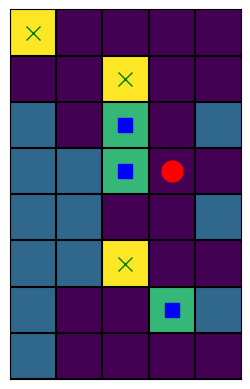

Final state visualization saved medium_map2 


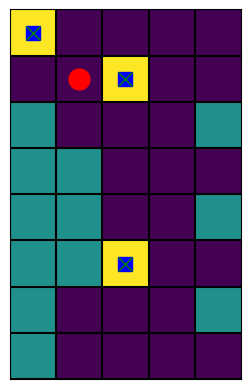


Solution visualization saved in tests/solutions/simulated_annealing/medium_map2

Testing hard_map1.yaml...
Solution found with 652 moves
States explored: 0
Pull moves used: 276
Time taken: 4.18 seconds
Initial state visualization saved hard_map1 


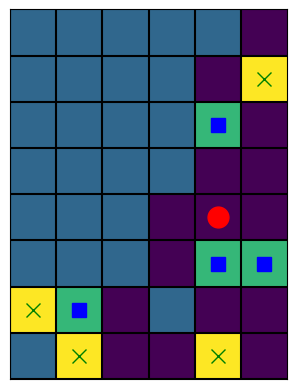

Final state visualization saved hard_map1 


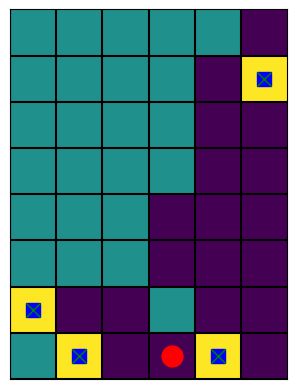


Solution visualization saved in tests/solutions/simulated_annealing/hard_map1

Testing hard_map2.yaml...
Solution found with 716 moves
States explored: 0
Pull moves used: 233
Time taken: 2.85 seconds
Initial state visualization saved hard_map2 


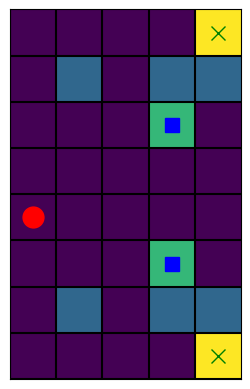

Final state visualization saved hard_map2 


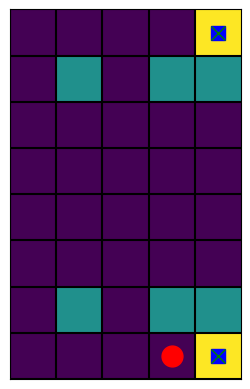


Solution visualization saved in tests/solutions/simulated_annealing/hard_map2

Testing large_map1.yaml...
Solution found with 624 moves
States explored: 0
Pull moves used: 208
Time taken: 3.18 seconds
Initial state visualization saved large_map1 


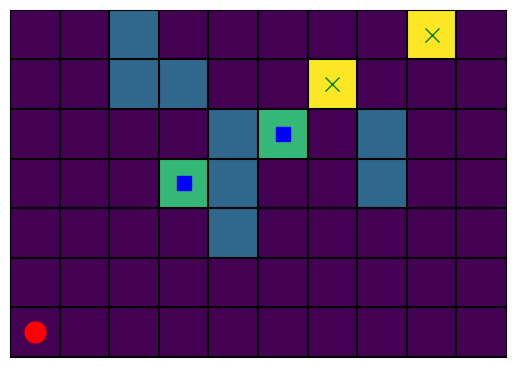

Final state visualization saved large_map1 


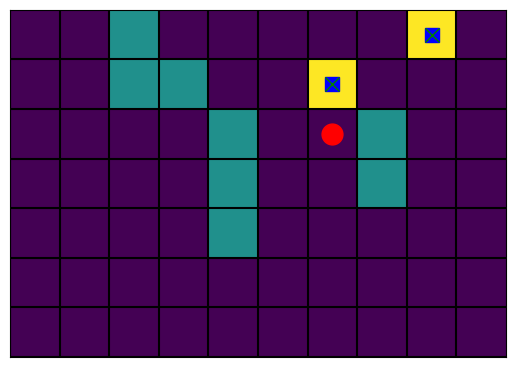


Solution visualization saved in tests/solutions/simulated_annealing/large_map1

Testing large_map2.yaml...
Solution found with 486 moves
States explored: 0
Pull moves used: 169
Time taken: 3.60 seconds
Initial state visualization saved large_map2 


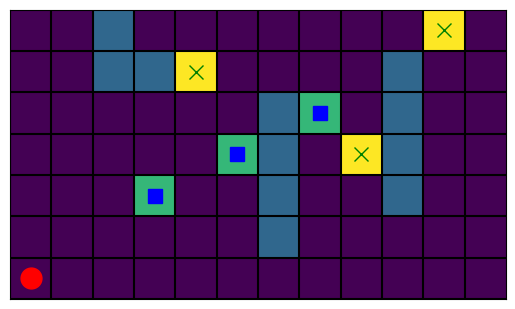

Final state visualization saved large_map2 


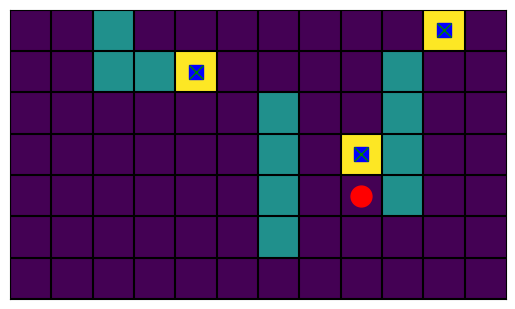


Solution visualization saved in tests/solutions/simulated_annealing/large_map2

Testing super_hard_map1.yaml...
Solution found with 345 moves
States explored: 0
Pull moves used: 139
Time taken: 18.94 seconds
Initial state visualization saved super_hard_map1 


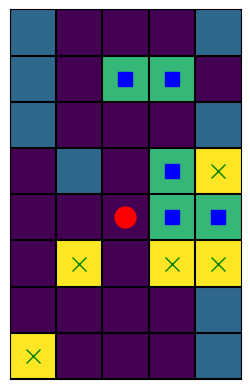

Final state visualization saved super_hard_map1 


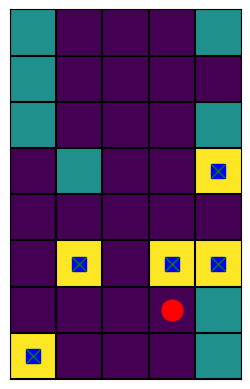


Solution visualization saved in tests/solutions/simulated_annealing/super_hard_map1


In [1]:
import os
import time
from typing import  Dict
from sokoban.map import Map
from search_methods.lrta_star import LRTAStar
from search_methods.simmulated_annealing import SimulatedAnnealing
def solve_and_visualize(solver, map_file: str, algorithm_name: str, quiet: bool = False) -> Dict:
    """Run solver on a map and collect metrics"""
    # Load the map
    initial_state = Map.from_yaml(map_file)

    # Time the solution
    start_time = time.time()
    solution = solver.solve(initial_state)
    solve_time = time.time() - start_time

    results = {
        'solved': solution is not None,
        'time': solve_time,
        'moves': len(solution) if solution else 0,
        'states_explored': getattr(solver, 'states_explored', 0),
        'pull_moves': sum(1 for move in solution if move >= 4) if solution else 0
    }

    if not quiet:
        if solution is None:
            print("No solution found!")
        else:
            print(f"Solution found with {results['moves']} moves")
            print(f"States explored: {results['states_explored']}")
            print(f"Pull moves used: {results['pull_moves']}")
            print(f"Time taken: {results['time']:.2f} seconds")

            # Save visualization in algorithm-specific subdirectory
            map_name = os.path.basename(map_file).replace(".yaml", "")
            output_dir = os.path.join(
                os.path.dirname(map_file),
                'solutions',
                algorithm_name.replace(' ', '_').lower(),
                map_name
            )
            os.makedirs(output_dir, exist_ok=True)

            state = initial_state.copy()
            #state.save_map(output_dir, f'{map_name}_initial_state')
            print(f"Initial state visualization saved {map_name} ")
            state.plot_map()

            for move in solution:
                state.apply_move(move)
            print(f"Final state visualization saved {map_name} ")
            state.plot_map()

            print(f"\nSolution visualization saved in {output_dir}")

    return results


def main():
    # List of test maps
    test_maps = [
        'tests/easy_map1.yaml',
        'tests/easy_map2.yaml',
        'tests/medium_map1.yaml',
        'tests/medium_map2.yaml',
        'tests/hard_map1.yaml',
        'tests/hard_map2.yaml',
        'tests/large_map1.yaml',
        'tests/large_map2.yaml',
        'tests/super_hard_map1.yaml'
    ]

    # Results storage
    results = []

    # Test LRTA*
    print("\n=== Testing LRTA* Algorithm ===")
    algorithm_name = 'LRTA*'

    for map_file in test_maps:
        import random
        random.seed()  # Ensure independent randomness for each run
        lrta_solver = LRTAStar(max_iterations=600000)  # New solver instance for each map
        print(f"\nTesting {os.path.basename(map_file)}...")
        result = solve_and_visualize(lrta_solver, map_file, algorithm_name)
        result['algorithm'] = algorithm_name
        result['map'] = os.path.basename(map_file)
        results.append(result)

    # Test Simulated Annealing
    print("\n=== Testing Simulated Annealing Algorithm ===")
    sa_solver = SimulatedAnnealing(
        initial_temp=100.0,
        cooling_rate=0.9999,
        min_temp=0.05,
        max_iterations=200000,
        restart_temp=50.0,
        plateau_limit=100,
    )
    algorithm_name = 'Simulated Annealing'

    for map_file in test_maps:
        print(f"\nTesting {os.path.basename(map_file)}...")
        result = solve_and_visualize(sa_solver, map_file, algorithm_name)
        result['algorithm'] = algorithm_name
        result['map'] = os.path.basename(map_file)
        results.append(result)

if __name__ == '__main__':
    main()

